# Preprocessing

Steps:
- [Data Cleaning](#1)
- [Outlier Handling](#2)
- [Feature Encoding](#3)
- [Feature Scaling](#4)

## Import Libraries and Load Data

In [80]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import optuna
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import optuna.visualization as vis

### Load and Inspect Data

In [24]:
df = pd.read_csv('../data/raw/dataset.csv')  

# check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   str    
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   str    
dtypes: float64(8), int64(4), str(2)
memory usage: 109.5 KB


In [25]:
df.nunique()

ID           800
No_Pation    961
Gender         3
AGE           50
Urea         110
Cr           113
HbA1c        111
Chol          77
TG            69
HDL           48
LDL           65
VLDL          60
BMI           64
CLASS          5
dtype: int64

Note: The unique values for Gender and Class are 3 and 5 which is unusual so we further look into their values

In [26]:
print(df['CLASS'].unique())
print(df['Gender'].unique())

<StringArray>
['N', 'N ', 'P', 'Y', 'Y ']
Length: 5, dtype: str
<StringArray>
['F', 'M', 'f']
Length: 3, dtype: str


<a id='1'></a>
### Data Cleaning

String Trimming and Case Consistency

In [27]:
df['CLASS'] = df['CLASS'].str.strip()
df['Gender'] = df['Gender'].str.upper()

print(df['CLASS'].unique())
print(df['Gender'].unique())

<StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str
<StringArray>
['F', 'M']
Length: 2, dtype: str


Drop Redundant Columns: We drop ID and No_Pation Column as they as no predictive power

In [28]:
df.drop(columns=['ID','No_Pation'], inplace=True)
df.head(2)

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N


<a id='2'></a>
### Outlier Handling

In [29]:
num_cols = ['Urea','Cr','HbA1c','Chol','TG','HDL','LDL','VLDL','BMI','AGE']

for col in num_cols:
    lower_bound = df[col].quantile(0.05)
    upper_bound = df[col].quantile(0.95)

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)


In [30]:
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,N
1,M,33,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,N
3,F,50,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,N
4,M,33,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


### Data Splitting

In [31]:
X = df.drop(columns=['CLASS'])  
y = df['CLASS']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class counts: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test  class counts: {pd.Series(y_test).value_counts().to_dict()}')


Train: (800, 11), Test: (200, 11)
Train class counts: {'Y': 675, 'N': 82, 'P': 43}
Test  class counts: {'Y': 169, 'N': 21, 'P': 10}


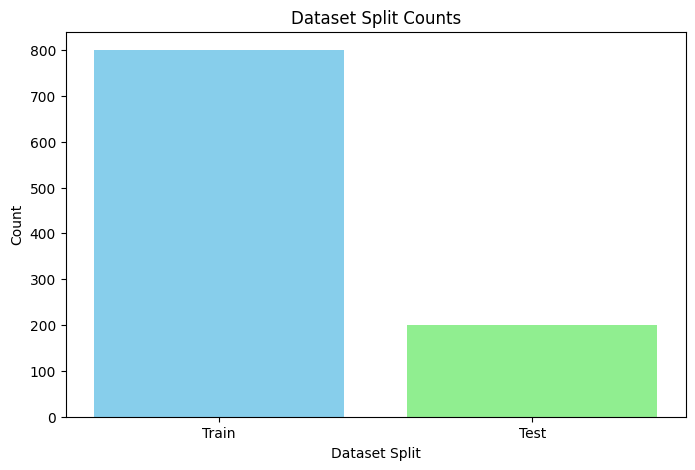

In [33]:
plt.figure(figsize=(8, 5))
plt.bar(['Train','Test'], [len(X_train), len(X_test)], color=['skyblue','lightgreen'])
plt.xlabel('Dataset Split')
plt.ylabel('Count')
plt.title('Dataset Split Counts')
plt.show()

### Feature Encoding

In [34]:

le = LabelEncoder()

y_train_processed = le.fit_transform(y_train)
y_test_processed = le.transform(y_test)

<a id='3'></a>
### Transformation Pipeline

In [35]:
num_cols = ['Urea','Cr','HbA1c','Chol','TG','HDL','LDL','VLDL','BMI','AGE']
cat_cols = ['Gender']

transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(), cat_cols)
    ])


### Logistic Regression

In [39]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')

train_pipe = ImbPipeline(
    steps=[
        ('transformer', transformer),
        ('smote', SMOTE()),
        ('lr', lr)
    ]
)

train_pipe.fit(X_train, y_train_processed)

,steps,"[('transformer', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The 

              precision    recall  f1-score   support

           N       0.84      1.00      0.91        21
           P       0.67      1.00      0.80        10
           Y       1.00      0.95      0.97       169

    accuracy                           0.95       200
   macro avg       0.84      0.98      0.90       200
weighted avg       0.97      0.95      0.96       200



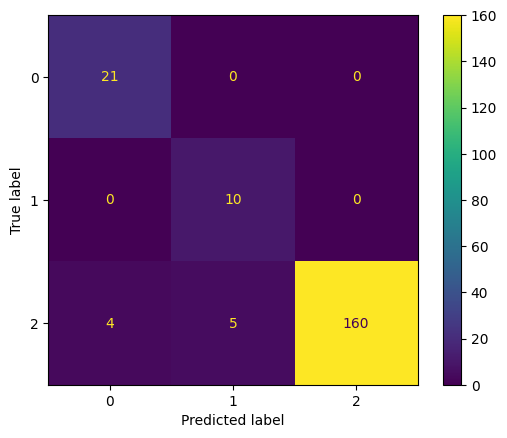

In [56]:
y_pred_test = train_pipe.predict(X_test)
print(classification_report(y_test_processed, y_pred_test, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(train_pipe, X_test, y_test_processed)

### DecisionTree Classifier

In [53]:
clf = DecisionTreeClassifier( random_state=42)

train_pipe_dt = ImbPipeline(
    steps=[
        ('transformer', transformer),
        ('sm', SMOTE(sampling_strategy='not majority', random_state=42)),
        ('clf', clf)
    ], 
    
)

train_pipe_dt.fit(X_train, y_train_processed)

,steps,"[('transformer', ...), ('sm', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The giv

              precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.80      0.89        10
           Y       0.99      1.00      0.99       169

    accuracy                           0.99       200
   macro avg       1.00      0.93      0.96       200
weighted avg       0.99      0.99      0.99       200



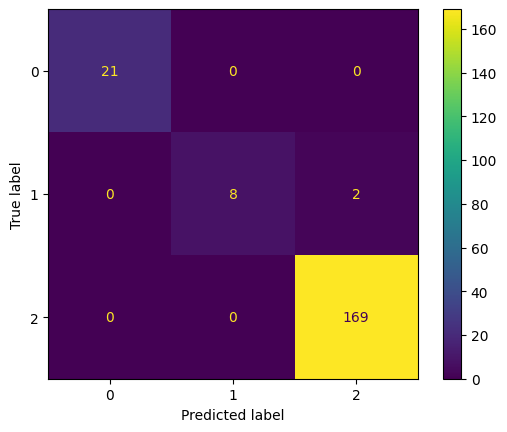

In [55]:
y_pred_test = train_pipe_dt.predict(X_test)
print(classification_report(y_test_processed, y_pred_test, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(train_pipe_dt, X_test, y_test_processed)

In [57]:
clf_complex = DecisionTreeClassifier( random_state=42, max_depth=15, min_samples_split=8)

train_pipe_dt = ImbPipeline(
    steps=[
        ('transformer', transformer),
        ('smote', SMOTE(sampling_strategy='not majority', random_state=42)),
        ('clf', clf_complex)
    ]
)

train_pipe_dt.fit(X_train, y_train_processed)

,steps,"[('transformer', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The 

              precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.60      0.75        10
           Y       0.98      1.00      0.99       169

    accuracy                           0.98       200
   macro avg       0.99      0.87      0.91       200
weighted avg       0.98      0.98      0.98       200



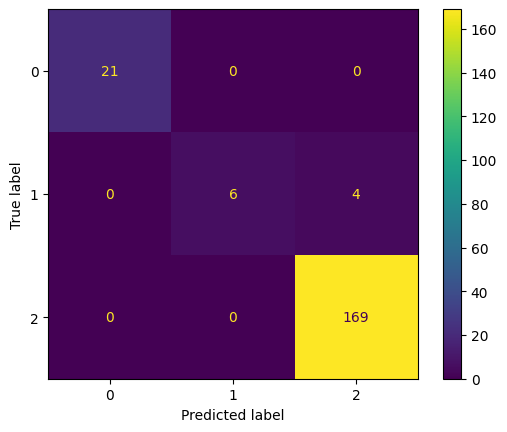

In [58]:
y_pred_test = train_pipe_dt.predict(X_test)
print(classification_report(y_test_processed, y_pred_test, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(train_pipe_dt, X_test, y_test_processed)

### RandomForest Classifier

In [59]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

rf_pipe = ImbPipeline(
    steps=[
        ('transformer', transformer),
        ('smote', SMOTE(sampling_strategy='not majority', random_state=42)),
        ('clf', rf)
    ]
)

rf_pipe.fit(X_train, y_train_processed)

,steps,"[('transformer', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The 

              precision    recall  f1-score   support

           N       0.95      1.00      0.98        21
           P       1.00      1.00      1.00        10
           Y       1.00      0.99      1.00       169

    accuracy                           0.99       200
   macro avg       0.98      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



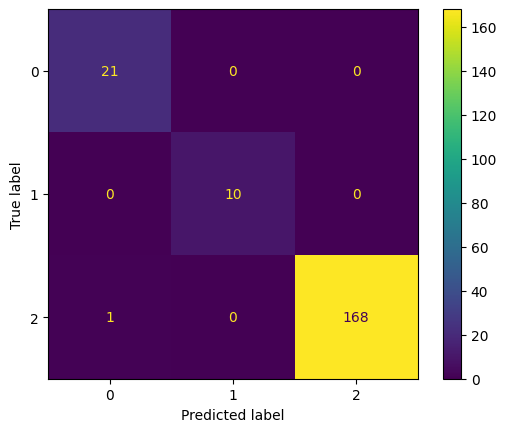

In [60]:
y_pred_test = rf_pipe.predict(X_test)
print(classification_report(y_test_processed, y_pred_test, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(rf_pipe, X_test, y_test_processed)

### XGBoost Classifier

XGBoost Performance:
              precision    recall  f1-score   support

           N       1.00      0.90      0.95        21
           P       1.00      0.90      0.95        10
           Y       0.98      1.00      0.99       169

    accuracy                           0.98       200
   macro avg       0.99      0.93      0.96       200
weighted avg       0.99      0.98      0.98       200



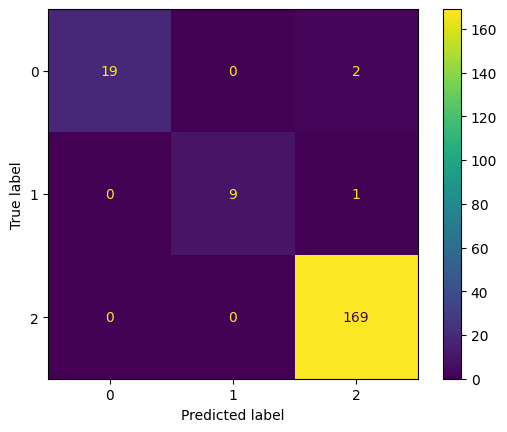

In [71]:
xgb_clf = XGBClassifier(eval_metric='mlogloss', random_state=42, )

# Build pipeline
xgb_pipe = Pipeline([
    ('transformer', transformer),
    ('xgb', xgb_clf)
])

# Train
xgb_pipe.fit(X_train, y_train_processed)

# Validate
y_test_pred = xgb_pipe.predict(X_test)

print("XGBoost Performance:")
print(classification_report(y_test_processed, y_test_pred, target_names=['N','P','Y']))
ConfusionMatrixDisplay.from_estimator(xgb_pipe, X_test, y_test_processed)

## Hyperparameter Tuning

In [76]:
def objective(trial):
    # Choose the model 
    classifier_name = trial.suggest_categorical('classifier', ['RandomForestClassifier', 'GradientBoostingClassifier', 'XGBClassifier', 'LogisticRegression'])
    
    if classifier_name == 'RandomForestClassifier':
        # Comprehensive RandomForest parameters
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 3, 30)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])
        
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            bootstrap=bootstrap,
            random_state=42
        )
    
    elif classifier_name == 'GradientBoostingClassifier':
        # Comprehensive GradientBoosting parameters
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        
        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            subsample=subsample,
            max_features=max_features,
            random_state=42
        )
    
    elif classifier_name == 'XGBClassifier':
        # Comprehensive XGBoost parameters
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
        reg_alpha = trial.suggest_float('reg_alpha', 0.0, 10.0)
        reg_lambda = trial.suggest_float('reg_lambda', 0.0, 10.0)
        
        model = XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_child_weight=min_child_weight,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            eval_metric='mlogloss',
            random_state=42
        )
    
    elif classifier_name == 'LogisticRegression':
        # Comprehensive Logistic Regression parameters
        C = trial.suggest_float('C', 0.001, 100.0, log=True)
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
        solver = 'saga'
        class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
        
        model = LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            class_weight=trial.suggest_categorical('class_weight', [None, 'balanced']),
            max_iter=5000, # Saga needs more iterations to converge
            random_state=42
        )
        
    pipe = ImbPipeline(
        steps=[
            ('transformer', transformer ),
            ('smote', SMOTE(sampling_strategy='not majority', random_state=42)),
            ('classifier', model)
        ]
    )
    
    # Evaluate model performance
    score = cross_val_score(pipe, X_train, y_train_processed, cv=5, scoring='accuracy').mean()
    return score


In [77]:
# Creating a study 
study = optuna.create_study(direction='maximize')
# Optimize the objective function
study.optimize(objective, n_trials=80)

[I 2026-02-20 23:45:32,406] A new study created in memory with name: no-name-0483a92f-bf27-4551-b1e9-b07ab0165191
[I 2026-02-20 23:45:38,987] Trial 0 finished with value: 0.97 and parameters: {'classifier': 'RandomForestClassifier', 'n_estimators': 460, 'max_depth': 23, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.97.
[I 2026-02-20 23:45:43,943] Trial 1 finished with value: 0.9812500000000002 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 395, 'learning_rate': 0.07416578916944153, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.9564664766934876, 'colsample_bytree': 0.6132157945175424, 'reg_alpha': 0.9758772103099322, 'reg_lambda': 6.853458157460954}. Best is trial 1 with value: 0.9812500000000002.
[I 2026-02-20 23:45:54,253] Trial 2 finished with value: 0.9774999999999998 and parameters: {'classifier': 'GradientBoostingClassifier', 'n_estimators': 244, 'learning_rate': 0.226126556391125

In [ ]:
vis.plot_optimization_history(study)

In [81]:
print(f"Best Trial Score: {study.best_value}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


Best Trial Score: 0.9875
Best Hyperparameters:
  classifier: XGBClassifier
  n_estimators: 376
  learning_rate: 0.1078582338030867
  max_depth: 6
  min_child_weight: 1
  subsample: 0.9761633897390365
  colsample_bytree: 0.7596070730636015
  reg_alpha: 0.7239369851405955
  reg_lambda: 3.3310251472298624
